<div style="border: 2px solid #FFA500; padding: 10px; border-radius: 5px; background-color: #FFFACD; color: black; text-align: center;">
  <h1 style="margin: 0;">Rice Husk Example 🌾</h1>
</div>

This example is based on the following publication: [Kätelhön et al. (2016)](https://doi.org/10.1021/acs.est.6b04270). The original example used for introducing the TCM deals with a simultaneous technology 🔨 and regional 🌐 choice problem. It can also be solved with PULPO. The superstructure can be seen below:

![Image Alt Text](data/system_boundaries_rice-superstructure_neutral.svg)

# Rice Example

#### Problem Formulation

The original problem formulation deals with an economic objective function, using factor constraints. With PULPO, the intention is to solve LCO problems with environmental objectives, but a function for economic factors could be considered for implementation as well, if data availability allows so. 

Hence, the adapted problem formulation can be stated as follows:

<div style="background-color: #f9f9f9; padding: 20px; border: 2px solid #ccc; border-radius: 10px; font-family: Arial, sans-serif;">

  <h2 style="color: #0073e6;">Goal and Scope</h2>
  <p>Find the optimal system configuration, minimizing the global warming potential. First, in an <b>unconstrained system</b>.</p>

  <div style="background-color: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 4px solid #0073e6;">
    <h3 style="color: #0073e6;">📦 Functional Unit</h3>
    <p>For demonstration purposes, a final demand of <b>1 Mt of processed rice</b> is specified.</p>
  </div>

  <div style="background-color: #fffae6; padding: 15px; margin: 15px 0; border-left: 4px solid #ffcc00;">
    <h3 style="color: #ffcc00;">🎯 Objective Function</h3>
    <p><b>Primary objective:</b> Global warming potential (GWP).</p>
  </div>

  <div style="background-color: #e6ffe6; padding: 15px; margin: 15px 0; border-left: 4px solid #228b22;">
    <h3 style="color: #228b22;">🔄 Possible Choices</h3>
    <ul>
      <li><b>Regional</b> 🌐: (Rice husk collection 1 / Rice husk collection 2 / ... / Rice husk collection 5)</li>
      <li><b>Technology</b> 🔨: (Rice husk boiler / Natural gas boiler / Wood pellet boiler)</li>
    </ul>
  </div>

  <div style="background-color: #fbe9e7; padding: 15px; margin: 15px 0; border-left: 4px solid #d32f2f;">
    <h3 style="color: #d32f2f;">⚙️ Additional Constraints</h3>
    <p>None.</p>
  </div>

</div>



##### **<u>Technosphere Matrix A</u>**
In the Technosphere, new choices are added in a **bottom-up** fashion, extending the square matrix:


$$
\scriptsize
\begin{array}{|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
 & \text{Rice} & \text{Rice} & \text{Natural gas} & \text{natural} & \text{Power} & \text{Transportation} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Wood pellet}} & \textcolor{darkorange}{\text{Burning of}} & \textcolor{orange}{\text{Rice husk}} & \textcolor{orange}{\text{Wood pellet}} \\
 & \text{factory} & \text{farming} & \text{boiler} & \text{gas supply} & \text{plant} & \text{by truck} & \textcolor{darkorange}{\text{collection 1}} & \textcolor{darkorange}{\text{collection 2}} & \textcolor{darkorange}{\text{collection 3}} & \textcolor{darkorange}{\text{collection 4}} & \textcolor{darkorange}{\text{collection 5}} & \textcolor{darkorange}{\text{supply}} & \textcolor{darkorange}{\text{rice husk}} & \textcolor{orange}{\text{boiler}} & \textcolor{orange}{\text{boiler}} \\
\hline
\text{Processed rice (in Mt)} & 1 & 0 & 0 & 0 & 0 & 0 & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\text{Unprocessed rice (in Mt)} & -1.15 & 1 & 0 & 0 & 0 & 0 & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\text{Thermal energy (in TWh)} & -2.2 & 0 & \cellcolor{orange}\textcolor{white}{1} & 0 & 0 & 0 & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \cellcolor{orange}\textcolor{white}{1} & \cellcolor{orange}\textcolor{white}{1} \\
\hline
\text{Natural gas (in TWh)} & 0 & 0 & -1.11 & 1 & 0 & 0 & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\text{Electricity (in TWh)} & -0.08 & 0 & 0 & 0 & 1 & 0 & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{darkorange}{-0.02} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\text{Transportation (in Gt*km)} & -0.35 & 0 & 0 & 0 & 0 & 1 & \textcolor{darkorange}{-0.12} & \textcolor{darkorange}{-0.24} & \textcolor{darkorange}{-0.36} & \textcolor{darkorange}{-0.48} & \textcolor{darkorange}{-0.6} & \textcolor{darkorange}{-0.1} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\textcolor{DodgerBlue}{\text{Rice husk at factory (in Mt)}} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \cellcolor{MediumOrchid}\textcolor{white}{1} & \cellcolor{MediumOrchid}\textcolor{white}{1} & \cellcolor{MediumOrchid}\textcolor{white}{1} & \cellcolor{MediumOrchid}\textcolor{white}{1} & \cellcolor{MediumOrchid}\textcolor{white}{1} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{MediumOrchid}{-0.23} & \textcolor{Thistle}{0} \\
\hline
\textcolor{DodgerBlue}{\text{Rice husk at farm (in Mt)}} & \textcolor{lightblue}{0} & \textcolor{DodgerBlue}{0.6} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{MediumOrchid}{-1} & \textcolor{MediumOrchid}{-1} & \textcolor{MediumOrchid}{-1} & \textcolor{MediumOrchid}{-1} & \textcolor{MediumOrchid}{-1} & \textcolor{Thistle}{0} & \textcolor{MediumOrchid}{-1} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} \\
\hline
\textcolor{DodgerBlue}{\text{Wood pellets (in Mt)}} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{lightblue}{0} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{MediumOrchid}{1} & \textcolor{Thistle}{0} & \textcolor{Thistle}{0} & \textcolor{MediumOrchid}{-0.25} \\
\hline
\end{array}
$$

##### <u>Biosphere Matrix B</u>
In the Biosphere, the corresponding elementary flows need to be added:

$$
\scriptsize
\begin{array}{|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
 & \text{Rice} & \text{Rice} & \text{Natural gas} & \text{natural} & \text{Power} & \text{Transportation} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Rice husk}} & \textcolor{darkorange}{\text{Wood pellet}} & \textcolor{darkorange}{\text{Burning of}} & \textcolor{orange}{\text{Rice husk}} & \textcolor{orange}{\text{Wood pellet}} \\
 & \text{factory} & \text{farming} & \text{boiler} & \text{gas supply} & \text{plant} & \text{by truck} & \textcolor{darkorange}{\text{collection 1}} & \textcolor{darkorange}{\text{collection 2}} & \textcolor{darkorange}{\text{collection 3}} & \textcolor{darkorange}{\text{collection 4}} & \textcolor{darkorange}{\text{collection 5}} & \textcolor{darkorange}{\text{supply}} & \textcolor{darkorange}{\text{rice husk}} & \textcolor{orange}{\text{boiler}} & \textcolor{orange}{\text{boiler}} \\
\hline
\text{CO2 (in Mt)} & 0 & 6.14 \times 10^{-1} & 2.27 \times 10^{-1} & 3.21 \times 10^{-2} & 1.10 \times 10^{0} & 5.76 \times 10^{-2} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{darkorange}{1.50 \times 10^{-1}} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\text{CH4 (in Mt)} & 0 & 1.33 \times 10^{-3} & 1.47 \times 10^{-4} & 1.50 \times 10^{-3} & 9.15 \times 10^{-4} & 6.97 \times 10^{-5} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{LightSalmon}{0} & \textcolor{darkorange}{2.56 \times 10^{-4}} & \textcolor{LightSalmon}{0} & \textcolor{PeachPuff}{0} & \textcolor{PeachPuff}{0} \\
\hline
\textcolor{FireBrick}{\text{Economic flows (in million \$)}} & \textcolor{FireBrick}{50} & \textcolor{FireBrick}{360} & \textcolor{LightCoral}{0} & \textcolor{FireBrick}{13} & \textcolor{FireBrick}{65} & \textcolor{FireBrick}{170} & \textcolor{FireBrick}{45} & \textcolor{FireBrick}{36} & \textcolor{FireBrick}{29} & \textcolor{FireBrick}{23} & \textcolor{FireBrick}{18} & \textcolor{FireBrick}{72} & \textcolor{LightCoral}{0} & \textcolor{LightCoral}{0} & \textcolor{LightCoral}{0} \\ \hline
\end{array}
$$

The final row for $\textcolor{FireBrick}{\text{economic flows}}$ is derived from the factor requirements matrix and the factor price vector from the original example. Only the cost for natural gas has been lowered slightly (16 --> 13), to enforce the economic competitiveness of the NG boiler. Although integrating economic flows into the biosphere matrix is unconventional, this approach will later be useful for demonstrating a multi-objective trade-off assessment, without the need to introduce additional elements to account for economic impacts.

##### <u>Characterization Factor Matrix Q</u>
The characterization factors are extended with a row for $\textcolor{FireBrick}{\text{Cost (in million \$)}}$:

$$
\scriptsize
\begin{array}{|c|c|c|c|}
\hline
 & \text{CO2} & \text{CH4} & \textcolor{FireBrick}{\text{Economic flows (in million \$)}}  \\
\hline
\text{GWP100 (in kg CO2e per kg)} & 1 & 25 & \textcolor{LightCoral}{0} \\
\hline
\textcolor{FireBrick}{\text{Cost (in million \$)}} & \textcolor{LightCoral}{0} & \textcolor{LightCoral}{0} & \textcolor{FireBrick}{1} \\
\hline
\end{array}
$$

_____
The whole system can be explored in [activity-browser](https://github.com/LCA-ActivityBrowser/activity-browser):

![Image Alt Text](data/rice_husk_database.PNG)

![Image Alt Text](data/rice_impact_categories.PNG)

<div style="border: 2px solid #FF6347; padding: 10px; border-radius: 5px; background-color: #FFE4E1; color: black; text-align: center;">
  <h2 style="margin: 0;">Resolution with PULPO 🐙</h2>
</div>

Import the necessary libraries

In [1]:
from pulpo import pulpo

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy

Plotting helpers used further below (plain matplotlib; nothing PULPO-specific).

In [3]:
def plot_demand(results_df):
    # Calculate contributions from Rice Husk zones
    for zone in range(1, 6):
        results_df[f'rice_husk_zone_{zone}'] = results_df['rice_husk_boiler'] * results_df[f'rice_husk_zone_{zone}']
    
    # Combine the data into a new DataFrame for plotting
    plot_data = results_df[['natural_gas_boiler', 'wood_pellet_boiler'] + [f'rice_husk_zone_{zone}' for zone in range(1, 6)]]
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(7, 4))
    
    # Colors: 5 similar shades of green, plus colors for natural gas and wood pellets
    colors = ['#2E86C1', '#E67E22', '#1E8449', '#229954', '#27AE60', '#2ECC71', '#82E0AA']
    
    # Create a stacked bar plot
    plot_data.plot(kind='bar', stacked=True, ax=ax1, color=colors, edgecolor='black')
    
    # Set the x-axis to the final demand values
    ax1.set_xticks(range(len(results_df['demand'])))
    ax1.set_xticklabels([f'{x:.2f}' for x in results_df['demand']])
    
    # Set labels and title
    ax1.set_xlabel('Final Demand for Processed Rice (in Mt/year)')
    ax1.set_ylabel('Thermal Energy Production Mix [-]')
    ax1.set_title('Thermal Energy Source Distribution')
    ax1.set_ylim(0, 1)
    
    # Add a scatter plot that doesn't show up in the plot area but is included in the legend
    ax1.scatter([np.nan], [np.nan], color='red', edgecolor='black', label='GWP')
    
    # Adjust legend
    ax1.legend(['GWP', 'Natural Gas', 'Wood Pellets', 'R. Husk Zone 1', 'R. Husk Zone 2', 
                'R. Husk Zone 3', 'R. Husk Zone 4', 'R. Husk Zone 5'], 
               loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=4)
    
    # Create a second y-axis for the GWP impact
    ax2 = ax1.twinx()
    ax2.plot(range(len(results_df['demand'])), results_df['impact'], color='red', markeredgecolor='black', marker='o', linestyle='')
    ax2.set_ylabel('GWP (in Mt CO₂-eq)')
    
    # Show the plot
    plt.show()


def plot_pareto(pareto_front):
    # Convert pareto_front into two separate lists for plotting
    costs, gwps = zip(*pareto_front)
    
    # Create the Pareto front plot
    plt.figure(figsize=(5, 4))
    plt.plot(costs, gwps, marker='o', color='b', linestyle=':', linewidth=2, markersize=10, markeredgecolor='black')
    
    # Set labels
    plt.xlabel('Cost (in $/kg pr. rice)', fontsize=14)
    plt.ylabel('GWP (in kg CO₂-eq/kg pr. rice)', fontsize=14)
    
    # Add grid for better readability
    plt.grid(True)
    
    plt.show()

def plot_cases():      
    # Data
    scenarios = ['Unconstrained', 'R. Husk Availability', 'Transport Limit', 'Wood Pellet Capacity']
    technologies = ['Natural Gas', 'Wood Pellets'] + [f'R. Husk Zone {i}' for i in range(1, 6)]
    
    # Percentage values for each technology under different scenarios
    data = {
        'Scenario': scenarios,
        'Natural Gas': [0.0, 0.0, 0.0, 52.2],
        'Wood Pellets': [0.0, 70.4, 83.1, 18.2],
        'R. Husk Zone 1': [100.0, 5.9, 5.9, 5.9],
        'R. Husk Zone 2': [0.0, 5.9, 5.9, 5.9],
        'R. Husk Zone 3': [0.0, 5.9, 5.1, 5.9],
        'R. Husk Zone 4': [0.0, 5.9, 0.0, 5.9],
        'R. Husk Zone 5': [0.0, 5.9, 0.0, 5.9],
        'GWP': [0.859, 0.919, 0.928, 1.264]
    }
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Set 'Scenario' as the index
    df.set_index('Scenario', inplace=True)
    
    # Prepare the DataFrame for plotting
    plot_data = df[technologies]
    
    # Colors: Define a cohesive color palette
    colors = ['#2E86C1', '#E67E22', '#1E8449', '#229954', '#27AE60', '#2ECC71', '#82E0AA']
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(8, 4))
    
    # Create a stacked bar plot
    plot_data.plot(kind='bar', stacked=True, ax=ax1, color=colors, edgecolor='black')
    
    # Set labels and title
    ax1.set_xlabel('Scenario', fontsize=12)
    ax1.set_ylabel('Percentage Allocation (%)', fontsize=12)
    ax1.set_ylim(0, 100)
    
    # Add percentage labels on each segment
    for idx, scenario in enumerate(df.index):
        cumulative = 0
        for tech_idx, tech in enumerate(technologies):
            value = df.loc[scenario, tech]
            if value > 0:
                height = value
                y = cumulative + height / 2
                ax1.text(idx, y, f'{value:.1f}%', ha='center', va='center', fontsize=9, color='white' if height > 15 else 'black')
                cumulative += height
    
    # Adjust x-axis labels
    ax1.set_xticklabels(df.index, rotation=0, fontsize=10)
    
    # Create a second y-axis for the GWP impact
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['GWP'], color='red', marker='o', markeredgecolor='black', linestyle='', linewidth=2, label='GWP')
    ax2.set_ylabel('Global Warming Potential (GWP)', fontsize=12)
    ax2.set_ylim(0.8, 1.3)
    ax2.tick_params(axis='y', labelsize=10)
    
    # Adjust legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=4, fontsize=10)
    
    # Add gridlines
    ax1.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()


Set the project, database and method (**objective function**). In this example, the rice husk case study is used, which can be installed via a PULPO function (```install_rice_husk_db```).

In [4]:
pulpo.install_rice_husk_db()
project = "rice_husk_example" 
database = "rice_husk_example_db"
method = "('my project', 'climate change')"

Elementary flow database created


Process database created


LCIA methods and CFs defined


Substitute with your working directory of choice. This directory will be used to store the results.

In [5]:
notebook_dir = os.path.dirname(os.getcwd())
directory = os.path.join(notebook_dir, 'data')

Create a **PulpoOptimizer** instance. This class is used to interact with the LCI database and solve the optimization problem. It is specified by the project, database, method and directory.

In [6]:
pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)

Import LCI data. After initializing the PulpoOptimizer instance, the LCI data is imported from the database.

In [7]:
pulpo_worker.get_lci_data()

Specify the **functional unit**. In this case, the functional unit is 1 Mt of processed rice. PULPO implements a search function (```retrieve_processes```) to find the processes that match the specified reference products (alternatively: keys, process name, region).

In [8]:
rice_factory = pulpo_worker.retrieve_processes(reference_products='Processed rice (in Mt)')

demand = {rice_factory[0]: 1}

Specify the **choices**. Here, the choices are regional 🌐 choices for rise husk collections, and technological ⛏ choices for boiler type selection.

The auxiliar choices are needed to resolve the issue that rice, when not used in the boiler must be burned instead. 

(*At this point, just accept. If you are curious about how this multi-functionality is technically adressed, refer to the paper, or reach out.*)

In [9]:
## Rise husk collection
rice_husk_processes = ["Rice husk collection 1",
              "Rice husk collection 2",
              "Rice husk collection 3",
              "Rice husk collection 4",
              "Rice husk collection 5",]
rice_husk_collections = pulpo_worker.retrieve_processes(processes=rice_husk_processes)

In [10]:
## Boilers
boiler_processes = ["Natural gas boiler",
                     "Wood pellet boiler",
                     "Rice husk boiler"]
boilers = pulpo_worker.retrieve_processes(processes=boiler_processes)

In [11]:
## Auxiliar (Ignore for now!)
auxiliar_processes = ["Rice husk market",
                       "Burning of rice husk"]
auxiliar = pulpo_worker.retrieve_processes(processes=auxiliar_processes)

In [12]:
## Combine to create the choices dictionary
## For each kind of choice, assign a 'label' (e.g. 'boilers')
## To each possible choice, assign a process capacity; float('inf') means no limit
choices = {'Rice Husk (Mt)': {rice_husk_collections[0]: float('inf'),
                              rice_husk_collections[1]: float('inf'),
                              rice_husk_collections[2]: float('inf'),
                              rice_husk_collections[3]: float('inf'),
                              rice_husk_collections[4]: float('inf')},
           'Thermal Energy (TWh)': {boilers[0]: float('inf'),
                                    boilers[1]: float('inf'),
                                    boilers[2]: float('inf')},
           'Auxiliar': {auxiliar[0]: float('inf'),
                        auxiliar[1]: float('inf')}}

**Instantiate** and **solve** the optimization model

In [13]:
pulpo_worker.instantiate(choices=choices, demand=demand)
results = pulpo_worker.solve()

Creating Instance


Instance created


optimal solution found: 


0.8585406610795238


**Save** and **summarize** the results

In [14]:
pulpo_worker.save_results(name='rice_example_unconstrained.xlsx')
pulpo_worker.summarize_results(zeroes=True)

Results saved to rice_example_unconstrained.xlsx


## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,0.858541


## Choices Made

### Rice Husk (Mt)

...

,Value,Capacity
Metadata,,
Rice husk boiler | Thermal energy from husk boiler (in TWh) | GLO,2.2,inf


### Auxiliar

,Value,Capacity
Metadata,,
Burning of rice husk | Burned rice husk (in Mt) | GLO,0.184,inf


## Constraints

'No constraint data to display.'

It can be seen that, in the unconstrained case minimizing the GWP, the optimal solution is to use the rice husk boiler and the rice husk collection 1. The minimum GWP is **0.859** Mt CO2-eq per Mt of processed rice. Let us store the relevant results:

So far, we said that the case is *unconstrained*. This means that we don't consider any relevant capacity constraints on any of the processes. Let's now move to the constrained case!

<div style="border: 2px solid #A9A9A9; padding: 10px; border-radius: 5px; background-color: #DCDCDC; color: black; text-align: center;">
  <h3 style="margin: 0;">Constrained Case 🔏</h3>
</div>

We will consider three different simple constrained cases:

![Image Alt Text](data/superstructure_constrained.svg)

#### Choice Capacity Constraints ↔

  <div style="background-color: #fbe9e7; padding: 15px; margin: 15px 0; border-left: 4px solid #d32f2f;">
    <h3 style="color: #d32f2f;">⚙️ Additional Constraints</h3>
    <p>Add a constraint to the rice husk collection of 0.03 Mt per zone.</p>
  </div>

In [15]:
choices_constrained = copy.deepcopy(choices)
choices_constrained['Rice Husk (Mt)'] = {rice_husk_collections[0]: 0.03,
                                         rice_husk_collections[1]: 0.03,
                                         rice_husk_collections[2]: 0.03,
                                         rice_husk_collections[3]: 0.03,
                                         rice_husk_collections[4]: 0.03}

Repeat the solution steps ...

In [16]:
pulpo_worker.instantiate(choices=choices_constrained, demand=demand)
results = pulpo_worker.solve()

Creating Instance


Instance created


optimal solution found: 


0.9186618840850095


In [17]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,0.918662


## Choices Made

### Rice Husk (Mt)

,Value,Capacity
Metadata,,
Rice husk collection 1 | Rice husk from region 1 (in Mt) | GLO,0.03,0.03
Rice husk collection 2 | Rice husk from region 2 (in Mt) | GLO,0.03,0.03
Rice husk collection 3 | Rice husk from region 3 (in Mt) | GLO,0.03,0.03
Rice husk collection 4 | Rice husk from region 4 (in Mt) | GLO,0.03,0.03
Rice husk collection 5 | Rice husk from region 5 (in Mt) | GLO,0.03,0.03


...

,Value,Capacity
Metadata,,
Wood pellet boiler | Thermal energy from wood pellet boiler (in TWh) | GLO,1.547826,inf
Rice husk boiler | Thermal energy from husk boiler (in TWh) | GLO,0.652174,inf


### Auxiliar

,Value,Capacity
Metadata,,
Burning of rice husk | Burned rice husk (in Mt) | GLO,0.54,inf


## Constraints

'No constraint data to display.'

When constraints are specified on the availability of rice husk, the optimizer chooses to use all the available rice husk that can be transported from every zone. The remaining thermal energy is provided by the wood pellet boiler.

##### Upper Limits ⬆

Upper limits can be enforced as well on processes that are not part of the choices. This can be done using the `upper_limit` parameter in the `instantiate` method. Let's see an example, where we limit the transportation process to 0.37 Gt*km (*This value has no rational meaning, and is just an example to demonstrate the upper limit functionality*):

  <div style="background-color: #fbe9e7; padding: 15px; margin: 15px 0; border-left: 4px solid #d32f2f;">
    <h3 style="color: #d32f2f;">⚙️ Additional Constraints</h3>
    <p>Add a constraint of 0.37 Gt*km to the availability of transportation.</p>
  </div>

In [18]:
# Retrieve the transport process
transportation = pulpo_worker.retrieve_processes(processes=["Transportation by truck"])

In [19]:
upper_limit = {transportation[0]: 0.37}

Repeat the solution steps, specifying now the "upper_limit" parameter during instantiation ...

In [20]:
pulpo_worker.instantiate(choices=choices_constrained, demand=demand, upper_limit=upper_limit)
results = pulpo_worker.solve()

Creating Instance


Instance created


optimal solution found: 


0.9275997924554046


In [21]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,0.9276


## Choices Made

### Rice Husk (Mt)

,Value,Capacity
Metadata,,
Rice husk collection 1 | Rice husk from region 1 (in Mt) | GLO,0.030000,0.03
Rice husk collection 2 | Rice husk from region 2 (in Mt) | GLO,0.030000,0.03
Rice husk collection 3 | Rice husk from region 3 (in Mt) | GLO,0.025556,0.03


...

### Auxiliar

,Value,Capacity
Metadata,,
Burning of rice husk | Burned rice husk (in Mt) | GLO,0.604444,inf


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
15,"(rice_husk_example_db, Transportation by truck)",Transportation by truck | Transportation (in G...,0.37,0.37


It can be seen that the optimizer chooses to source rice husk from zones 1-3 and the remaining demand for thermal heat is supplied by the wood pellet boiler.

##### Upper Limit on Wood Pellet Boiler

  <div style="background-color: #fbe9e7; padding: 15px; margin: 15px 0; border-left: 4px solid #d32f2f;">
    <h3 style="color: #d32f2f;">⚙️ Additional Constraints</h3>
    <p>Add a constraint of 0.1 Mt to the supply of wood pellets.</p>
  </div>

In [22]:
wood_pellet_supply = pulpo_worker.retrieve_processes(processes=["Wood pellet supply"])
upper_limit = {wood_pellet_supply[0]: 0.1}

In [23]:
pulpo_worker.instantiate(choices=choices_constrained, demand=demand, upper_limit=upper_limit)
results = pulpo_worker.solve()

Creating Instance


Instance created


optimal solution found: 


1.2643985959378212


In [24]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.264399


## Choices Made

### Rice Husk (Mt)

,Value,Capacity
Metadata,,
Rice husk collection 1 | Rice husk from region 1 (in Mt) | GLO,0.03,0.03
Rice husk collection 2 | Rice husk from region 2 (in Mt) | GLO,0.03,0.03
Rice husk collection 3 | Rice husk from region 3 (in Mt) | GLO,0.03,0.03
Rice husk collection 4 | Rice husk from region 4 (in Mt) | GLO,0.03,0.03
Rice husk collection 5 | Rice husk from region 5 (in Mt) | GLO,0.03,0.03


...

### Auxiliar

,Value,Capacity
Metadata,,
Burning of rice husk | Burned rice husk (in Mt) | GLO,0.54,inf


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
12,"(rice_husk_example_db, Wood pellet supply)",Wood pellet supply | Wood pellets (in Mt) | GLO,0.1,0.1


##### Summary of Cases:

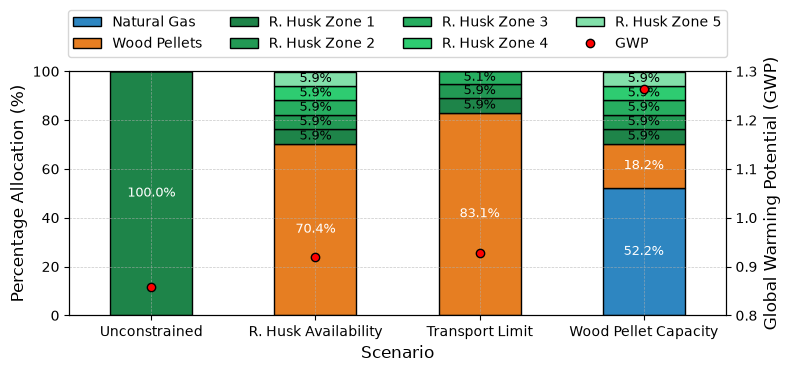

In [25]:
plot_cases()

<div style="border: 2px solid #0073e6; padding: 8px; border-radius: 5px; background-color: #f0f8ff; color: black; text-align: center;">
  <h2 style="margin: 0;">Final Demand Variation 📦</h2>
</div>

In this section, we are varying the final demand and observe the consequence on the total GWP impact, as well as the technology and regional composition.

The following code performs a loop over various demand values ranging from 0.05 Mt to 1.00 Mt of rice.

> **Disclaimer**:  
> The syntax used here to access the internal variables of the optimization problem is not as intuitive and requires profound knowledge of the data structures of PULPO (e.g., the process map). We are working on simplifying this, to make it easier for users to access these variables outside the "summarize" and "save" functions.

  <div style="background-color: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 4px solid #0073e6;">
    <h3 style="color: #0073e6;">📦 Functional Unit</h3>
    <p>A final demand range of <b>0.05 to 1.00 Mt of processed rice</b> is specified.</p>
  </div>

In [26]:
# List of final demand values
final_demand_values = [i * 0.05 for i in range(1, 21)]

# Define the entries to be analysed
process_map = pulpo_worker.lci_data['process_map']
boilers = ['Natural gas boiler', 'Wood pellet boiler', 'Rice husk boiler']
zones = [f'Rice husk collection {i}' for i in range(1, 6)]

# Mapping process IDs
boiler_ids = [process_map[('rice_husk_example_db', boiler)] for boiler in boilers]
zone_ids = [process_map[('rice_husk_example_db', zone)] for zone in zones]

# Initialize results dictionary
results_list = {
    'demand': [],
    'impact': [],
    'natural_gas_boiler': [],
    'wood_pellet_boiler': [],
    'rice_husk_boiler': [],
    **{f'rice_husk_zone_{i}': [] for i in range(1, 6)}
}

for demand_value in final_demand_values:
    # Set the demand for processed rice
    demand_dict = {rice_factory[0]: demand_value}
    
    # Instantiate and solve the optimization model
    pulpo_worker.instantiate(choices=choices_constrained, demand=demand_dict, upper_limit=upper_limit)
    results = pulpo_worker.solve()
    print()
    
    # Append the results to the list
    results_list['demand'].append(demand_value)
    results_list['impact'].append(pulpo_worker.instance.OBJ())

    # Normalize and append boiler results
    total_boilers = sum(pulpo_worker.instance.scaling_vector[i].value for i in boiler_ids)
    for boiler, boiler_id in zip(boilers, boiler_ids):
        results_list[boiler.lower().replace(' ', '_')].append(
            pulpo_worker.instance.scaling_vector[boiler_id].value / total_boilers
        )

    # Normalize and append zone results
    total_zones = sum(pulpo_worker.instance.scaling_vector[i].value for i in zone_ids)
    for i, zone_id in enumerate(zone_ids, start=1):
        results_list[f'rice_husk_zone_{i}'].append(
            pulpo_worker.instance.scaling_vector[zone_id].value / total_zones
        )

# Convert the results_list dictionary to a pandas DataFrame
results_df = pd.DataFrame(results_list)

Creating Instance


Instance created


optimal solution found: 


0.04292703305397619


Creating Instance


...

1.1842176259045074


Creating Instance


Instance created


optimal solution found: 


1.2643985959378212


Plot the results in a bar chart. While this approach works, the visualization of results could benefit from standardized plots, which we are planning to implement. Currently, users need to manually extract the relevant values and create the visualizations that best meet their needs.

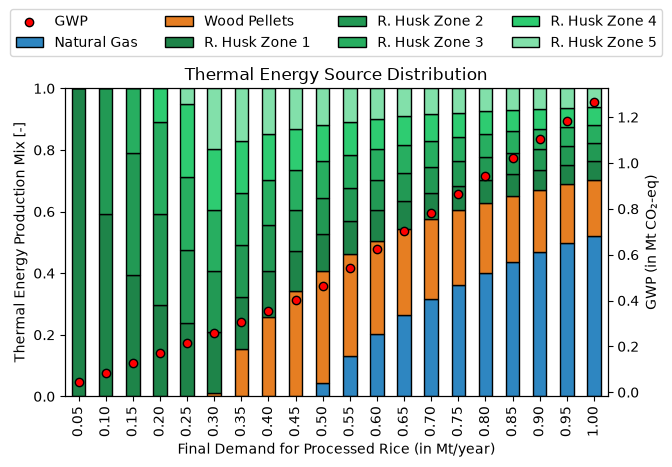

In [27]:
plot_demand(results_df)

<div style="border: 2px solid #00CED1; padding: 10px; border-radius: 5px; background-color: #E0FFFF; color: black;"> 
  🛠️ This could be implemented as a standard function in <strong>PULPO</strong>.
</div>

<div style="border: 2px solid #ffcc00; padding: 8px; border-radius: 5px; background-color: #fffae6; color: black; text-align: center;">
  <h2 style="margin: 0;">Multi-Objective / Trade-off 🎯</h2>
</div>

In this section, we will first optimize the system using the $\textcolor{FireBrick}{\text{economic flows}}$ as objective, and then analyse the trade-off. To that end, we will create a new pulpo_worker, which imports both impact categories. For now, we specify a weight of 0 for the environmental and a weight of 1 for the economic objective:

  <div style="background-color: #fffae6; padding: 15px; margin: 15px 0; border-left: 4px solid #ffcc00;">
    <h3 style="color: #ffcc00;">🎯 Objective Function</h3>
    <p><b>Primary objective:</b> Cost.</p>
  </div>

In [28]:
methods = {"('my project', 'climate change')": 0, "('my project', 'economic flow')": 1}

In [29]:
pulpo_worker_multi = pulpo.PulpoOptimizer(project, database, methods, directory)
pulpo_worker_multi.get_lci_data()

With the worker created, we can proceed to instantiate and solve the problem, now with the economic objective function:

In [30]:
pulpo_worker_multi.instantiate(choices=choices_constrained, demand=demand, upper_limit=upper_limit)
results = pulpo_worker_multi.solve()

Creating Instance


Instance created


optimal solution found: 


560.1599916511774


In [31]:
pulpo_worker_multi.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'economic flow')",1,560.159992


## Choices Made

### Rice Husk (Mt)

,Value,Capacity
Metadata,,


...

,Value,Capacity
Metadata,,
Natural gas boiler | Thermal energy from natural gas boiler (in TWh) | GLO,2.2,inf


### Auxiliar

,Value,Capacity
Metadata,,
Burning of rice husk | Burned rice husk (in Mt) | GLO,0.69,inf


## Constraints

'No constraint data to display.'

As anticipated, the natural gas option minimizes costs (0.56 $/kg processed rice). However, this cost reduction leads to a significant increase in the climate change impact (1.26 → 1.60 kg CO2e/kg processed rice). Given these trade-offs, how does the Pareto front appear? For that purpose, we are going to use the epsilon-constrained method, constraining the environmental objective between the values corresponding to the environmental optimum and the economic optimum:

In [32]:
lower_impact = pulpo_worker.instance.impacts["('my project', 'climate change')"].value
upper_impact = pulpo_worker_multi.instance.impacts_calculated["('my project', 'climate change')"].value

In [33]:
epsilon_list = np.linspace(lower_impact, upper_impact, num=5)

Indicator constraints can be specified in PULPO using the `upper_imp_limit` parameter of the instantiate function, as can be seen in the loop below:

  <div style="background-color: #fffae6; padding: 15px; margin: 15px 0; border-left: 4px solid #ffcc00;">
    <h3 style="color: #ffcc00;">🎯 Objective Function</h3>
    <p><b>Primary objective:</b> Cost.</p>
    <p><b>Secondary objective:</b> Global warming potential (GWP) --> Constrainted in relevant range via "upper_imp_limit".</p>
  </div>

In [34]:
# Initialize an empty list to store the Pareto front data
pareto_front = []

gw_category = "('my project', 'climate change')"
ef_category = "('my project', 'economic flow')"

for epsilon in epsilon_list:
    # Adjust the internal objective weights
    epsilon_constraint = {"('my project', 'climate change')": epsilon}
    pulpo_worker_multi.instantiate(choices=choices_constrained, demand=demand, upper_limit=upper_limit, upper_imp_limit=epsilon_constraint)
    results = pulpo_worker_multi.solve()

    # Calculate the impacts
    impacts = {x: pulpo_worker_multi.instance.impacts[x].value for x in pulpo_worker_multi.instance.impacts}
    
    # Save the impacts in the Pareto front list (cost divided by 1000)
    pareto_front.append((impacts[ef_category]/1000, impacts[gw_category]))
    
    # Print the impacts for each iteration
    print(f"Cost [$/kg processed rice]:{impacts[ef_category]/1000}")
    print(f"GWP [kg CO2-eq/kg processed rice]: {impacts[gw_category]}")
    print()

Creating Instance


Instance created


optimal solution found: 


566.0239046365155


Cost [$/kg processed rice]:0.5660239046365154


...

Instance created


optimal solution found: 


560.1599916511774


Cost [$/kg processed rice]:0.5601599916511774


GWP [kg CO2-eq/kg processed rice]: 1.6036194006662787


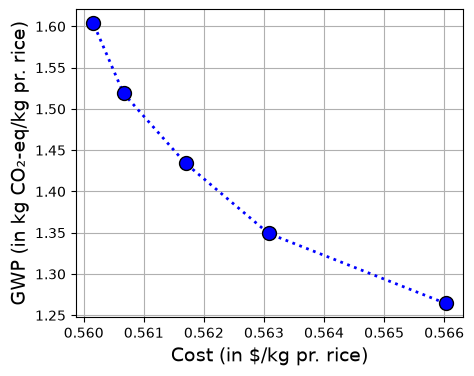

In [35]:
plot_pareto(pareto_front)

This type of (_constrained_) trade-off assessment highlights the inherent compromises involved in designing a production system with multiple criteria. In this example, the two extreme points (known as **anchor** points) demonstrate that a significant reduction in GWP (from 1.60 to 1.26 kg CO2-eq) can be achieved with only a slight increase in cost (from 0.560 to 0.566 \$). The Pareto front, defined by the 5 points shown, illustrates how balanced solutions can be realized.

<div style="border: 2px solid #00CED1; padding: 10px; border-radius: 5px; background-color: #E0FFFF; color: black;"> 
  🛠️ This could be implemented as a standard function in <strong>PULPO</strong>.
</div>

____

<div style="border: 2px solid #B0B0B0; padding: 8px; border-radius: 5px; background-color: #E0E0E0; color: black; text-align: center;">
  <h3 style="margin: 0;">Internal Constraint due to Multi-Functionality</h3>
</div>

Following the notion highlighted at the end of the previous section, let's investigate what happens if more thermal energy is required than the one that can be provided by the rice husk. This is done by adding another demand for the functional unit:

<div style="
    background-color: var(--background-highlight, #f0f8ff);
    padding: 15px;
    margin: 15px 0;
    border-left: 4px solid var(--accent-color, #0073e6);
">
    <h3 style="color: var(--accent-color, #0073e6);">📦 Functional Unit</h3>
    <p>A final demand range of <b>1.00 Mt of processed rice</b> is specified, in addition to <b>10 TWh of thermal energy</b>.</p>
</div>


In [36]:
demand_thermal = {rice_factory[0]: 1,
          'Thermal Energy (TWh)': 10}

In [37]:
pulpo_worker.instantiate(choices=choices, demand=demand_thermal)
results = pulpo_worker.solve()

Creating Instance


Instance created


optimal solution found: 


1.2195709588130852


In [38]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.219571


## Choices Made

### Rice Husk (Mt)

,Value,Capacity
Metadata,,
Rice husk collection 1 | Rice husk from region 1 (in Mt) | GLO,0.69,inf


...

,Value,Capacity
Metadata,,
Wood pellet boiler | Thermal energy from wood pellet boiler (in TWh) | GLO,9.2,inf
Rice husk boiler | Thermal energy from husk boiler (in TWh) | GLO,3.0,inf


### Auxiliar

,Value,Capacity
Metadata,,


## Constraints

'No constraint data to display.'

As can be seen from the choices made by the optimizer, the rice husk boiler is used to its full capacity, conditioned by the demand for rice:

$$
1 \, \text{Mt processed rice} \times 1.15 \frac{\text{Mt unprocessed rice}}{\text{Mt processed rice}} \times 0.6 \frac{\text{Mt Rice husk}}{\text{Mt unprocessed rice}} = 0.69 \, \text{Mt Rice husk} 
$$

The rest of the thermal energy is provided by the wood pellet boiler.
